In [9]:
#import packages 


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc
import numpy as np
from scipy.stats import linregress
from scipy.stats import stats

In [10]:
#reading files 
# combined U-Th Column sediment pteropod data and Me/Ca sediment pteropod data

sedidata = pd.read_excel('UTh and MeCa combined sediment pteropods.xlsx', sheet_name= 'combined sedimentary pteropods',header=1, skiprows=[3, 5, 12]) 
sedidatacsv = "UTh and MeCa combined sediment pteropods.csv"
sedidata.to_csv(sedidatacsv, index=False)
sedidatacsv = pd.read_csv(sedidatacsv)

n = sedidata['number']
print(sedidata.columns)

Index(['Type', 'ID', 'Label', 'Cleaning', 'number', 'Sr/Ca [mmol/mol]',
       'Ba/Ca [umol/mol]', 'U/Ca [nmol/mol]', 'Na_Ca [mmol/mol]',
       'Mg_Ca [mmol/mol]', 'Mn_Ca [umol/mol]', 'Fe_Ca [umol/mol]',
       'Al_Ca [umol/mol]', '230Th/238U A.R.', '± 2 s.e.', '230Th/234U A.R.',
       '± 2 s.e..1', '234U (dpm/g)', '± 2 s.e..2', '238U (dpm/g)',
       '± 2 s.e..3', '[234U] nmols/ mol Ca', '[238U] nmols/ g CaCO3',
       '[234U] nmols/ Ca mol', '[238U]nmols/ Ca mol', '[234U]', '[238U]',
       '[234U]/[238U]', '± 2 s.e..4', 'Measured U/Ca [nmol/mol]',
       'Unnamed: 30', 'Unnamed: 31'],
      dtype='object')


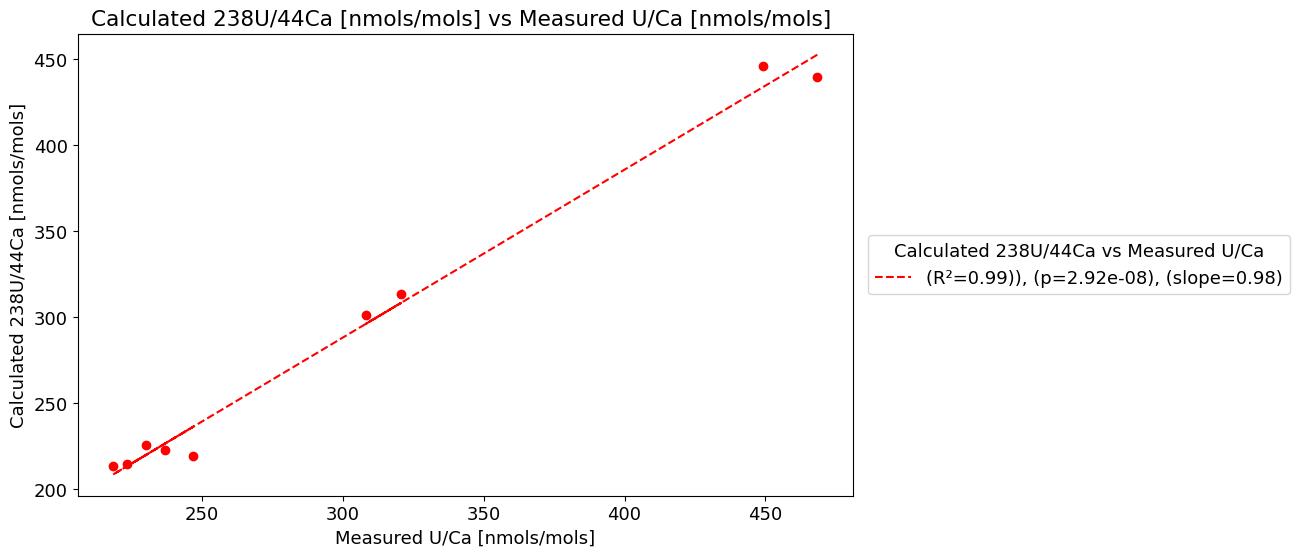

In [11]:
#Graph 1: sedimentary measured U nmols/Ca mols Ratios vs sedimentary columns 238U nmols/44Ca mols calculated

#index data
# measured U nmols/Ca mols from cleaned pteropods (excluding contaminated values)
U_CaMeas = sedidata['U/Ca [nmol/mol]']

#calculated U nmols/Ca mols from column pteropods (excluding contaminated values)
U_CaCalc = sedidata['[238U]nmols/ Ca mol']

# calulate linear regression
slope, intercept, r_value, p_value, std_err = linregress( U_CaMeas, U_CaCalc)
regression_y = slope * U_CaMeas + intercept
r_squared = r_value**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(U_CaMeas, U_CaCalc, color = 'r')

#plot linear regression
plt.plot(U_CaMeas, regression_y, label=f'(R²={r_squared:.2f})), (p={p_value:.2e}), (slope={slope:.2f})', color='r', linestyle='--')

# axis labels 
plt.xlabel('Measured U/Ca [nmols/mols]')
plt.ylabel('Calculated 238U/44Ca [nmols/mols]')

#plot title
plt.title('Calculated 238U/44Ca [nmols/mols] vs Measured U/Ca [nmols/mols] ')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='Calculated 238U/44Ca vs Measured U/Ca', borderaxespad=0)
plt.show()



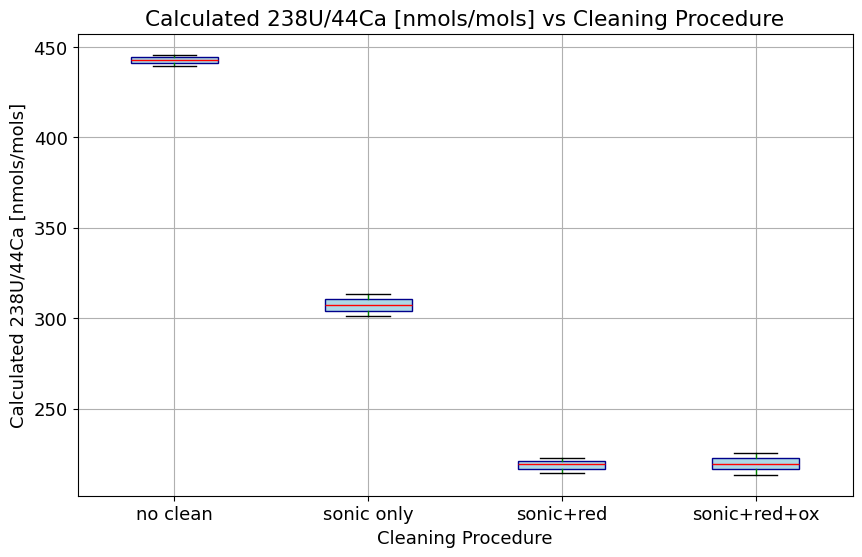

In [36]:
# Graph 2: sedimentary pteropods columns 238U nmols/44Ca mols calculated vs cleaning procedures

noclean      = sedidatacsv[sedidatacsv['Cleaning'] == 'NO']
sonic        = sedidatacsv[sedidatacsv['Cleaning'] == 'SON']
redsonic     = sedidatacsv[sedidatacsv['Cleaning'] == 'SON-RED']
oxredsonic   = sedidatacsv[sedidatacsv['Cleaning'] == 'SON-RED-OX']

# #index data by cleaning type
# noclean = sedidatacsv[sedidatacsv['Cleaning'].str.contains('NO')]
# sonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('SON')]

# #regex gets rid of regex operator of "+"
# redsonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('SON-RED', regex=False)]
# oxredsonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('SON-RED-OX', regex=False)]


# getting U nmols/ Ca mols from each cleaning type 
nocleanU = noclean['[238U]nmols/ Ca mol']
sonicU = sonic['[238U]nmols/ Ca mol']
redsonicU = redsonic['[238U]nmols/ Ca mol']
oxredsonicU = oxredsonic['[238U]nmols/ Ca mol']

#getting error bars
noerr = noclean['± 2 s.e..4']
sonerr = sonic['± 2 s.e..4']
redsonerr = redsonic['± 2 s.e..4']
oxredsonerr =oxredsonic['± 2 s.e..4']


#combining data
cleantype = nocleanU, sonicU, redsonicU, oxredsonicU
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('Calculated 238U/44Ca [nmols/mols]')

#plot title
plt.title('Calculated 238U/44Ca [nmols/mols] vs Cleaning Procedure')

#add grid lines
plt.grid()

plt.show()

1.138403054186125
1.1427774448758021


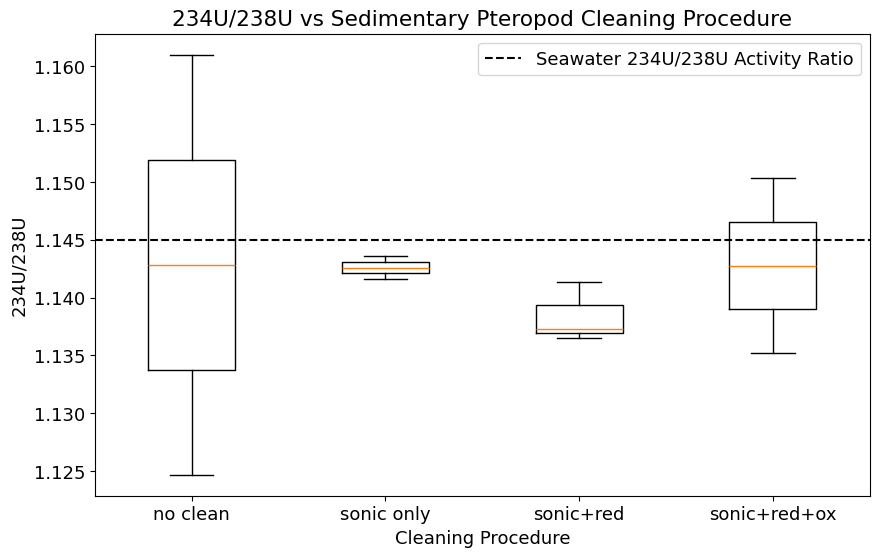

In [13]:
#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure



# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

#combining data
cleantype = noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning)



#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Sedimentary Pteropod Cleaning Procedure')

print(sum(redsonic234U_238U)/len(redsonic234U_238U))

print(sum(oxredsonic234U_238U)/len(oxredsonic234U_238U))

plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend()
plt.show()

0    1
1    1
2    2
3    2
4    3
5    3
6    3
7    4
8    4
Name: number, dtype: int64
1.138403054186125
1.1427774448758021


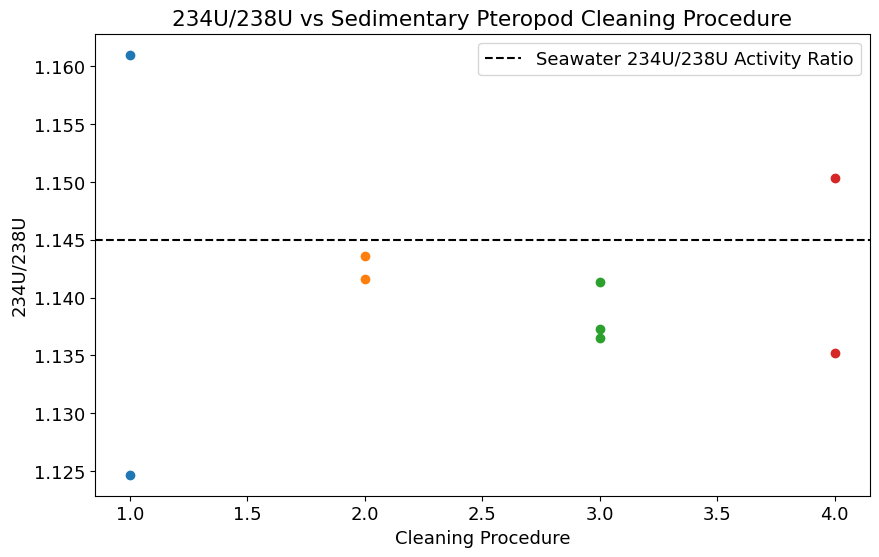

In [14]:
#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure


# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

# 

print(n)
#combining data
cleantype = noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot


plt.scatter(n[0:2], noclean234U_238U)
plt.scatter(n[2:4], sonic234U_238U)
plt.scatter(n[4:7], redsonic234U_238U)
plt.scatter(n[7:9], oxredsonic234U_238U)


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Sedimentary Pteropod Cleaning Procedure')

print(sum(redsonic234U_238U)/len(redsonic234U_238U))

print(sum(oxredsonic234U_238U)/len(oxredsonic234U_238U))

plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend()

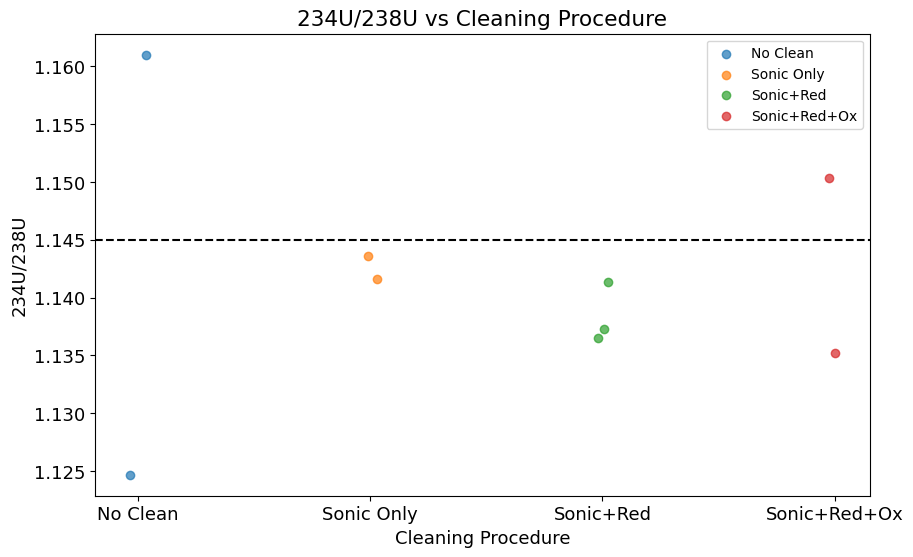

In [15]:
#graph 4 bar plots sedimentary pteropods columns 234U/238U mols vs cleaning procedure

# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']



#combining data
cleantype = [noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U]
cleaning = ['No Clean','Sonic Only','Sonic+Red','Sonic+Red+Ox']

#create figure
plt.figure(figsize=(10, 6))

#create scatterplot
#enumerate allows for cleantypes to be numbered to be able to scatter plot
for i, values in enumerate(cleantype):
    x = (i+1) + np.random.uniform(-0.04, 0.04, size=len(values)) # so points don’t overlap on x axis 
    plt.scatter(x, values, alpha=0.7)

#replace numbers with category labels
plt.xticks(range(1, len(cleaning)+1), cleaning)


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Cleaning Procedure')
plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')

#plot legend
plt.legend(cleaning, fontsize = 10)

#add grid lines
plt.show()


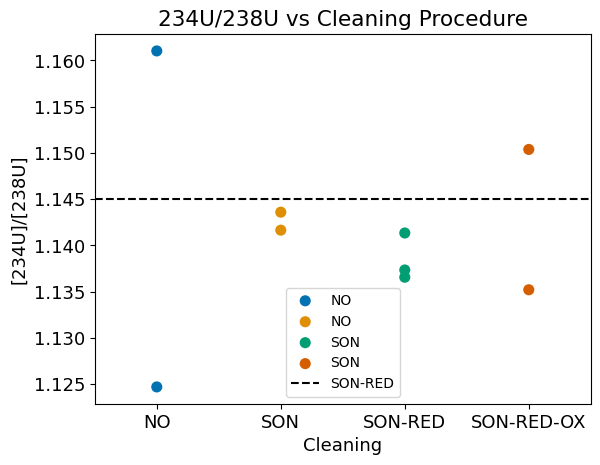

In [18]:
#add error bars 
grouped = sedidata.groupby('Cleaning')['[234U]/[238U]']
means = grouped.mean()
ses = grouped.std(ddof=1) / np.sqrt(grouped.count())
two_se = 2 * ses


# plt.figure(figsize=(10,6))
sns.stripplot(data=sedidata, x='Cleaning', y='[234U]/[238U]', hue='Cleaning',jitter = False, palette='colorblind', size =8)
# sns.pointplot(data=sedidata, x="Cleaning", y="[234U]/[238U]", errorbar="se", color = 'black', capsize=.2, err_kws={'linewidth': 0.8, 'color': 'black'}, join = False)
# # x locations for each cleaning category
# x_positions = range(len(means))



plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend(sedidata['Cleaning'], fontsize = 10)
plt.title('234U/238U vs Cleaning Procedure')

plt.show()




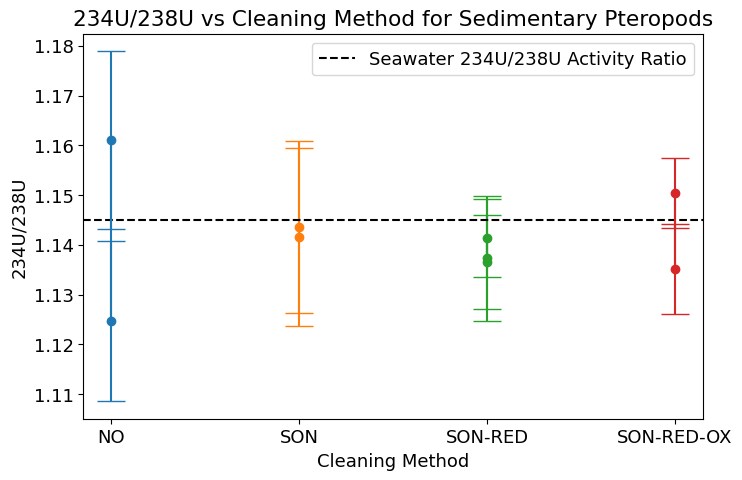

In [46]:
plt.close('all')

#create figure
plt.figure(figsize = (8,5))

#enumerate cleanign types
cleaning_types = ['NO','SON','SON-RED','SON-RED-OX']
xmap = {name: i for i, name in enumerate(cleaning_types)}



plt.scatter([xmap["NO"]]*len(noclean), noclean234U_238U)
plt.scatter([xmap["SON"]]*len(sonic), sonic234U_238U)
plt.scatter([xmap["SON-RED"]]*len(redsonic234U_238U), redsonic234U_238U)
plt.scatter([xmap["SON-RED-OX"]]*len(oxredsonic234U_238U), oxredsonic234U_238U)

#labeling xticks with cleaning procedure
plt.xticks(
    ticks=list(xmap.values()),   # numeric positions (0,1,2,3)
    labels=list(xmap.keys()),    # your category names
)

sedierr = sedidata['± 2 s.e..4']
#error bars 
plt.errorbar([xmap["NO"]]*len(noclean), noclean234U_238U, yerr = noerr, xerr = None, capsize = 10)
plt.errorbar([xmap["SON"]]*len(sonic), sonic234U_238U, yerr = sonerr, xerr = None, capsize = 10)
plt.errorbar([xmap["SON-RED"]]*len(redsonic234U_238U), redsonic234U_238U, yerr = redsonerr, xerr = None, capsize = 10)
plt.errorbar([xmap["SON-RED-OX"]]*len(oxredsonic234U_238U), oxredsonic234U_238U, yerr = oxredsonerr, xerr = None, capsize = 10)


#label axes
plt.xlabel('Cleaning Method')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Cleaning Method for Sedimentary Pteropods')
plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend()



plt.show()


In [22]:
#two sample t test noclean vs sonic
stats.ttest_ind(a = noclean234U_238U, 
                  b = sonic234U_238U, equal_var = False )

/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_19925/2478428492.py:2: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.ttest_ind(a = noclean234U_238U,


TtestResult(statistic=0.01330951498696787, pvalue=0.9915180539394429, df=1.00573436615448)

In [24]:
#two sample t test sonic vs redsonic
stats.ttest_ind(a = sonic234U_238U, 
                  b = redsonic234U_238U, equal_var = False )

/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_19925/59549715.py:2: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.ttest_ind(a = sonic234U_238U,


TtestResult(statistic=2.3737802433420763, pvalue=0.09856854079644231, df=2.986199514658678)

In [26]:
#two sample t test redsonic vs oxredsonic
stats.ttest_ind(a = redsonic234U_238U, 
                  b = oxredsonic234U_238U, equal_var = False )

/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_19925/3413325303.py:2: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.ttest_ind(a = redsonic234U_238U,


TtestResult(statistic=-0.5659542623837838, pvalue=0.6666075315975123, df=1.0769122225885983)

138.403054186125
142.77744487580202
4    137.330571
5    141.330649
6    136.547943
Name: [234U]/[238U], dtype: float64


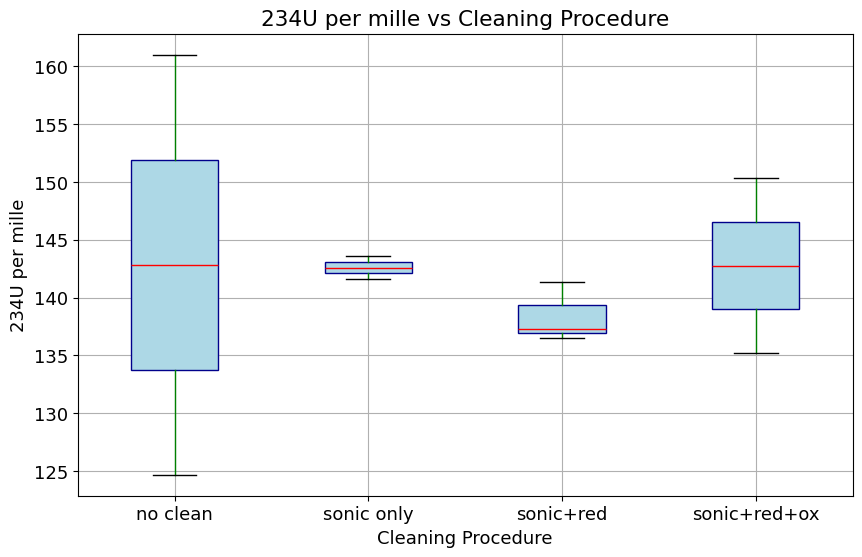

In [28]:
#graph 5: d234U per mille

#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure



# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

noclean234U = (noclean234U_238U - 1)*1000
sonic234U = (sonic234U_238U - 1)*1000
redsonic234U = (redsonic234U_238U - 1)*1000
oxredsonic234U = (oxredsonic234U_238U - 1)*1000

#combining data
cleantype = noclean234U, sonic234U, redsonic234U, oxredsonic234U
cleaning = {'no clean' : nocleanU,'sonic only': sonicU, 'sonic+red' : redsonicU,'sonic+red+ox' : oxredsonicU}

#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))



#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U per mille')

#plot title
plt.title('234U per mille vs Cleaning Procedure')

#add grid lines
plt.grid()

print(sum(redsonic234U)/len(redsonic234U))

print(sum(oxredsonic234U)/len(oxredsonic234U))

print(redsonic234U)


